# Inroduction (by GN)

Classification margin of an entry is defined as the opposite of the ratio above: how distant, as a percentage, the most similar domain is compared to the second most similar domain. 

Our k-nn classification is deterministic but based on an embedding model which is train stochastically. Any retraining, even on the entry dataset, will therefore produce variations in the classification.

This notebook tests the hyposesis that the entries with a higher margin are more robust to variation in classification due to this stochastic effect.

To test this we use the index.json from two classifications from the entries in the 7th edition of Enc. Britannica. The first index, `2026-07-18fix1`, has a margin column and information about nearest domain name and the similarity score. Method: for each entry in that first index, find the matching entry in `2026-07-18retrained` and check if it is assigned to another domain or if the domain was preserved. Then investigate the correlation between entry margin and preservation of domain. Ignore all entries with a similarity score of 0 in either index.

# Data analysis (by coding assistant, opencode/GLM 5.2)



In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append(str(Path.cwd().parent))
from helpers import settings

VARIANT_A = '2026-07-18fix1'
VARIANT_B = '2026-07-18retrained'
EDITION = 7


## Load the two indexes

Read each variant's `index.json` (table orientation) and keep edition 7. With `orient='table'` and `primaryKey=['index']`, pandas sets the entry id as the DataFrame index. Only `2026-07-18fix1` carries a precomputed `margin` column.

In [2]:
indexes = {}
for variant in [VARIANT_A, VARIANT_B]:
    path = Path(settings.DATA_PATH, variant, 'index.json')
    df = pd.read_json(path, orient='table')
    df = df[df['edition'] == EDITION]
    indexes[variant] = df
    print(f'{variant}: {len(df)} entries, {df["semantic_search-label"].nunique()} domains')

keys_a = set(indexes[VARIANT_A].index)
keys_b = set(indexes[VARIANT_B].index)
print(f'Common keys: {len(keys_a & keys_b)}, only in A: {len(keys_a - keys_b)}, only in B: {len(keys_b - keys_a)}')


2026-07-18fix1: 21118 entries, 9 domains


2026-07-18retrained: 21118 entries, 8 domains
Common keys: 21118, only in A: 0, only in B: 0


## Build the comparison table

Inner-join the two indexes on the entry id. Per the study design, ignore entries with a similarity score of 0 in either index. An entry is **preserved** when its domain in A equals its domain in B.

In [3]:
df_a = indexes[VARIANT_A]
df_b = indexes[VARIANT_B]

df = df_a[['semantic_search-label', 'semantic_search-score', 'margin']].join(
    df_b[['semantic_search-label', 'semantic_search-score']],
    how='inner', lsuffix='_a', rsuffix='_b'
)
df = df.rename(columns={
    'semantic_search-label_a': 'label_a',
    'semantic_search-score_a': 'score_a',
    'semantic_search-label_b': 'label_b',
    'semantic_search-score_b': 'score_b',
})

df = df[(df['score_a'] > 0) & (df['score_b'] > 0)].copy()
df = df[df['margin'].notna()]
df['margin'] = df['margin'].astype(int)
df['preserved'] = df['label_a'] == df['label_b']

total = len(df)
preserved = int(df['preserved'].sum())
print(f'{preserved} of {total} entries ({preserved / total * 100:.1f}%) kept their domain after retraining')


17059 of 20487 entries (83.3%) kept their domain after retraining


## Preservation rate by margin

Group entries into 10% margin bins and compute the domain-preservation rate in each bin. If the hypothesis holds, preservation should increase with margin.

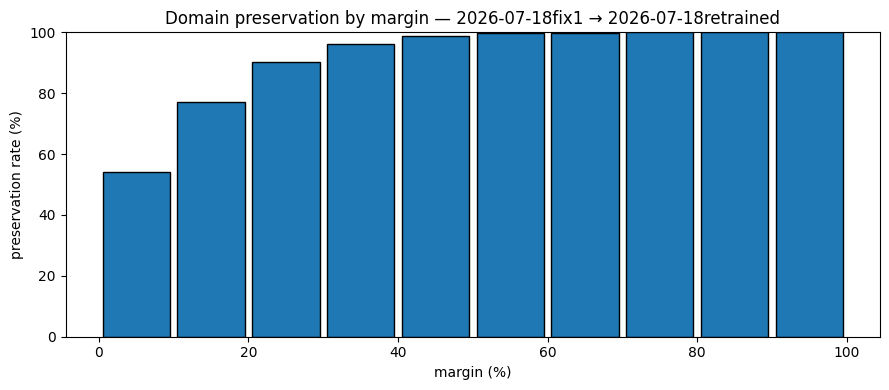

,margin_bin,count,preserved,rate
0,0,4335,2347,54.140715
1,10,4056,3122,76.972387
2,20,3586,3231,90.100390
3,30,2987,2871,96.116505
4,40,2313,2283,98.702983
5,50,1619,1615,99.752934
6,60,1041,1040,99.903939
7,70,439,439,100.000000
8,80,100,100,100.000000
9,90,11,11,100.000000


In [4]:
BIN_WIDTH = 10
df['margin_bin'] = (df['margin'] // BIN_WIDTH * BIN_WIDTH).astype(int)

by_bin = df.groupby('margin_bin').agg(
    count=('preserved', 'size'),
    preserved=('preserved', 'sum'),
).reset_index()
by_bin['rate'] = by_bin['preserved'] / by_bin['count'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_bin['margin_bin'] + BIN_WIDTH / 2, by_bin['rate'],
       width=BIN_WIDTH * 0.9, edgecolor='black')
ax.set_xlabel('margin (%)')
ax.set_ylabel('preservation rate (%)')
ax.set_title(f'Domain preservation by margin — {VARIANT_A} → {VARIANT_B}')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

by_bin


## Correlation between margin and preservation

Point-biserial correlation (binary preserved vs continuous margin) and Spearman rank correlation across all eligible entries, plus a linear fit on the bin-level preservation rates.

In [5]:
preserved_int = df['preserved'].astype(int)

r_pb, p_pb = stats.pointbiserialr(preserved_int, df['margin'])
rho, p_rho = stats.spearmanr(df['margin'], preserved_int)

bin_mids = by_bin['margin_bin'] + BIN_WIDTH / 2
slope, intercept, r_value, p_value, se = stats.linregress(bin_mids, by_bin['rate'])

print(f'Point-biserial r = {r_pb:.3f} (p = {p_pb:.2e})')
print(f'Spearman rho      = {rho:.3f} (p = {p_rho:.2e})')
print(f'Bin-level linear fit: slope = {slope:.3f} %/bin, R² = {r_value ** 2:.3f} (p = {p_value:.2e})')


Point-biserial r = 0.403 (p = 0.00e+00)
Spearman rho      = 0.440 (p = 0.00e+00)
Bin-level linear fit: slope = 0.385 %/bin, R² = 0.601 (p = 8.40e-03)


## Margin distribution: preserved vs changed

Compare the margin of entries that kept their domain with those that switched.

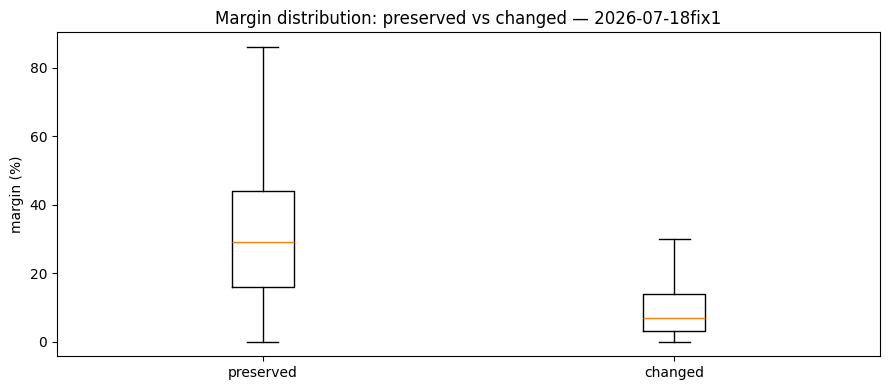

preserved: n=17059, median 29.0%, mean 31.1%
changed:  n=3428, median 7.0%, mean 10.0%


In [6]:
pres = df[df['preserved']]['margin']
chng = df[~df['preserved']]['margin']

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([pres, chng], tick_labels=['preserved', 'changed'], showfliers=False)
ax.set_ylabel('margin (%)')
ax.set_title(f'Margin distribution: preserved vs changed — {VARIANT_A}')
plt.tight_layout()
plt.show()

print(f'preserved: n={len(pres)}, median {pres.median():.1f}%, mean {pres.mean():.1f}%')
print(f'changed:  n={len(chng)}, median {chng.median():.1f}%, mean {chng.mean():.1f}%')


## Preservation by domain

How stable each domain is across retraining, regardless of margin.

In [7]:
by_domain = df.groupby('label_a').agg(
    count=('preserved', 'size'),
    preserved=('preserved', 'sum'),
).reset_index()
by_domain['rate'] = by_domain['preserved'] / by_domain['count'] * 100
by_domain = by_domain.sort_values('rate', ascending=False).reset_index(drop=True)
by_domain


,label_a,count,preserved,rate
0,useful_arts,6584,5742,87.211422
1,fine_arts,1440,1237,85.902778
2,natural_science,2354,1993,84.664401
3,philosophy,1930,1611,83.471503
4,civil_history,1639,1336,81.513118
5,natural_history,2497,2027,81.177413
6,sacred_history,2960,2327,78.614865
7,theology,1083,786,72.576177
